In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("dataset.csv")
df.head()

,student_id,age,gender,country,major,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,...,internet_quality,mental_stress_level,AI_tool_usage_hours,favorite_AI_tool,note_taking_method,exam_preparation_days,coffee_consumption_per_day,extracurricular_hours_per_week,final_exam_score,assignment_score
0,S00001,23,Female,Germany,Law,4,3.81,4.2,96,6.2,...,Average,4.8,1.5,Claude,Digital,15,3,7.6,100,100
1,S00002,26,Female,USA,Economics,2,3.46,3.3,94,6.6,...,Average,3.9,2.3,Gemini,Mixed,11,3,5.2,100,83
2,S00003,18,Female,Canada,Medicine,3,4.00,4.5,100,6.3,...,Average,4.8,0.0,NaN,Mixed,12,3,4.6,100,100
3,S00004,20,Male,Australia,Physics,4,3.77,5.8,97,7.1,...,Good,5.9,2.9,Gemini,Mixed,11,1,4.0,100,98
4,S00005,28,Female,Australia,Medicine,2,4.00,3.1,96,8.4,...,Good,3.1,1.5,ChatGPT,Handwritten,15,4,1.4,100,94


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      10000 non-null  str    
 1   age                             10000 non-null  int64  
 2   gender                          10000 non-null  str    
 3   country                         10000 non-null  str    
 4   major                           10000 non-null  str    
 5   university_year                 10000 non-null  int64  
 6   GPA                             10000 non-null  float64
 7   study_hours_per_day             10000 non-null  float64
 8   class_attendance_percent        10000 non-null  int64  
 9   sleep_hours                     10000 non-null  float64
 10  screen_time_hours               10000 non-null  float64
 11  social_media_hours              10000 non-null  float64
 12  gaming_hours                    10000 non-nu

student_id                           0
age                                  0
gender                               0
country                              0
major                                0
university_year                      0
GPA                                  0
study_hours_per_day                  0
class_attendance_percent             0
sleep_hours                          0
screen_time_hours                    0
social_media_hours                   0
gaming_hours                         0
exercise_hours_per_week              0
part_time_job                        0
relationship_status                  0
family_income_level                  0
internet_quality                     0
mental_stress_level                  0
AI_tool_usage_hours                  0
favorite_AI_tool                  1720
note_taking_method                   0
exam_preparation_days                0
coffee_consumption_per_day           0
extracurricular_hours_per_week       0
final_exam_score         

In [4]:
df = df.drop('favorite_AI_tool', axis=1)

In [5]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
country                           0
major                             0
university_year                   0
GPA                               0
study_hours_per_day               0
class_attendance_percent          0
sleep_hours                       0
screen_time_hours                 0
social_media_hours                0
gaming_hours                      0
exercise_hours_per_week           0
part_time_job                     0
relationship_status               0
family_income_level               0
internet_quality                  0
mental_stress_level               0
AI_tool_usage_hours               0
note_taking_method                0
exam_preparation_days             0
coffee_consumption_per_day        0
extracurricular_hours_per_week    0
final_exam_score                  0
assignment_score                  0
dtype: int64

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
df.head()

,age,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,screen_time_hours,social_media_hours,gaming_hours,exercise_hours_per_week,...,major_Physics,major_Psychology,part_time_job_Yes,relationship_status_Single,family_income_level_Low,family_income_level_Middle,internet_quality_Good,internet_quality_Poor,note_taking_method_Handwritten,note_taking_method_Mixed
0,23,4,3.81,4.2,96,6.2,3.9,3.3,0.0,2.1,...,False,False,True,True,False,False,False,False,False,False
1,26,2,3.46,3.3,94,6.6,4.9,3.2,2.7,5.0,...,False,False,False,True,True,False,False,False,False,True
2,18,3,4.00,4.5,100,6.3,3.7,1.4,0.0,2.6,...,False,False,True,False,False,False,False,False,False,True
3,20,4,3.77,5.8,97,7.1,6.9,3.7,2.1,3.2,...,True,False,False,True,False,False,True,False,False,True
4,28,2,4.00,3.1,96,8.4,4.8,0.6,0.0,4.4,...,False,False,True,False,False,True,True,False,True,False


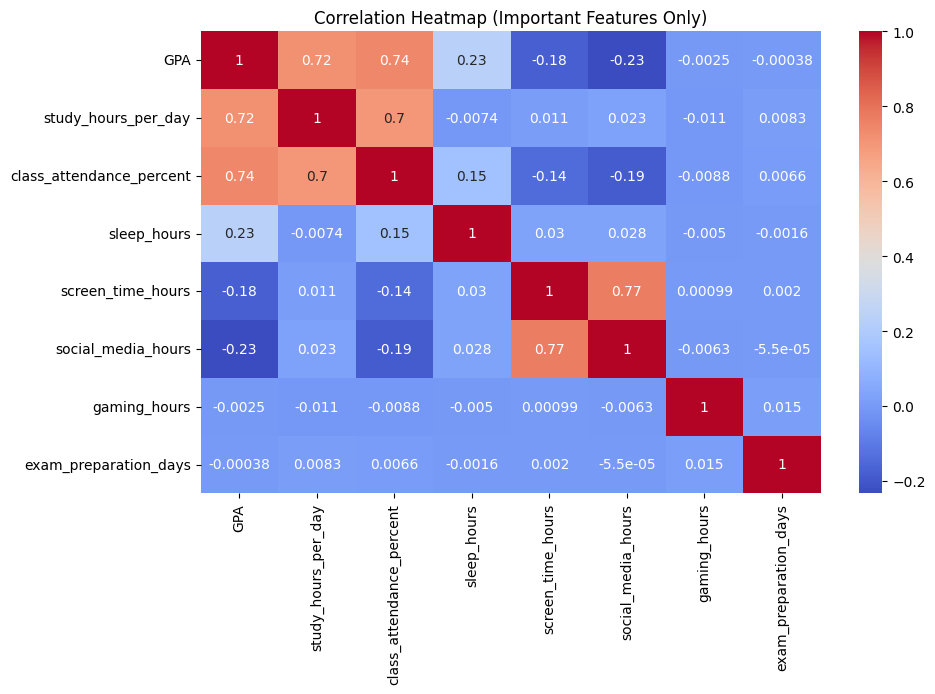

In [8]:
numeric_cols = [
    'GPA',
    'study_hours_per_day',
    'class_attendance_percent',
    'sleep_hours',
    'screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'exam_preparation_days'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Important Features Only)")
plt.show()

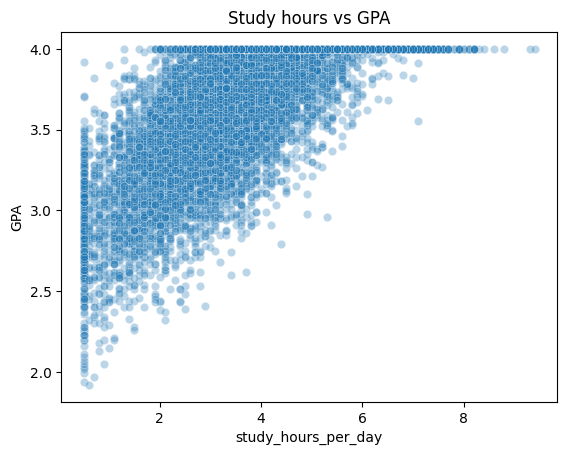

In [9]:
sns.scatterplot(x=df['study_hours_per_day'],y=df['GPA'],alpha=0.3)
plt.title("Study hours vs GPA")
plt.show()

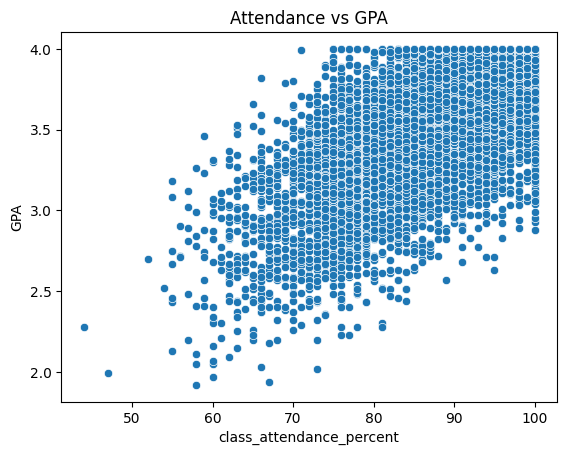

In [10]:
sns.scatterplot(x=df['class_attendance_percent'],y=df['GPA'])
plt.title("Attendance vs GPA")
plt.show()

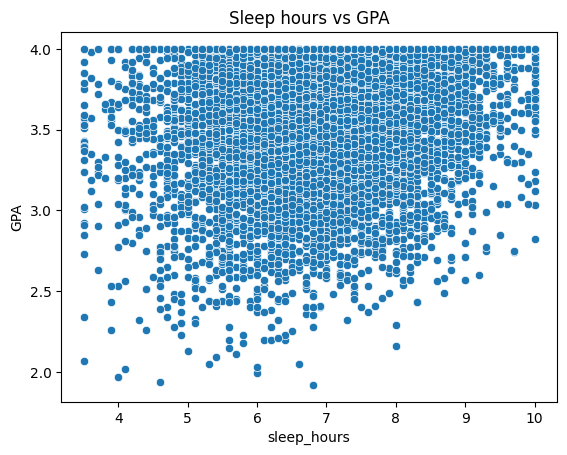

In [11]:
sns.scatterplot(x=df['sleep_hours'],y=df['GPA'])
plt.title('Sleep hours vs GPA')
plt.show()

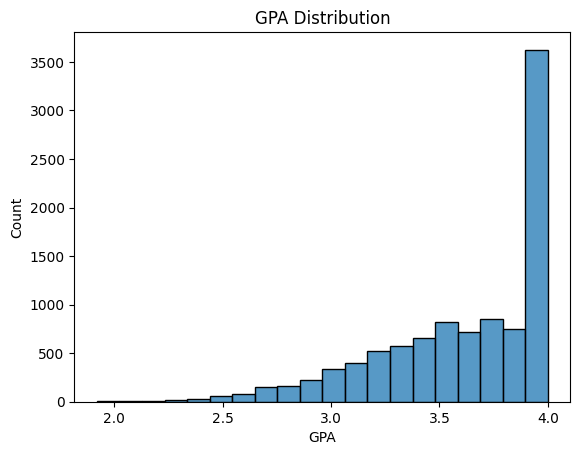

In [12]:
sns.histplot(df['GPA'], bins=20)
plt.title("GPA Distribution")
plt.show()

In [13]:
X = df.drop("GPA", axis=1)
y = df["GPA"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Initial Model (High Complexity - Large Size)

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.13815560000000002
R2 Score: 0.7706956348825691


In [17]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

### Optimized Model

The initial model resulted in a large file size (~50MB), which caused deployment issues.  
To address this, the model complexity was reduced by limiting the number of estimators and tree depth.

This significantly reduced the model size while maintaining good performance.

In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [19]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))